In [1]:
#pip install pytorch-msssim

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve


import pandas as pd
import os
from PIL import Image
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_msssim import ssim

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ GPU available: {torch.cuda.is_available()}")
print(f"✅ Using device: {device}")
print("\n🎉 You're all set!")

✅ PyTorch version: 2.8.0+cpu
✅ GPU available: False
✅ Using device: cpu

🎉 You're all set!


In [2]:
rootPath = 'C:/Users/deana/Downloads/RetinalDiseaseDetectionAutoencoder'
dataPath = 'C:/Users/deana/Downloads/RetinalDiseaseDetectionAutoencoder/data/datasets/normal'

In [5]:
sizes = set()
for root, dirs, files in os.walk(dataPath):
    for fname in files:
        if fname.endswith(('.jpg', '.jpeg', '.png')):
            w, h = Image.open(os.path.join(root, fname)).size
            sizes.add((w, h))

print(f'Unique sizes found: {sizes}')
print(f'All same size: {len(sizes) == 1}')

Unique sizes found: {(224, 224)}
All same size: True


In [6]:
BATCH_SIZE = 32
SEED = 42

temp_loader = DataLoader(
    [transforms.ToTensor()(Image.open(os.path.join(dataPath, f)).convert('RGB'))
     for f in os.listdir(dataPath) if f.endswith(('.jpg','.jpeg','.png'))],
    batch_size=64, shuffle=False
)

mean = torch.zeros(3)
std = torch.zeros(3)
n = 0
for imgs in temp_loader:
    mean += imgs.mean(dim=[0,2,3]); std += imgs.std(dim=[0,2,3]); n += 1
mean /= n; std /= n
print(f'mean={mean.tolist()}\nstd= {std.tolist()}')


mean=[0.14712372422218323, 0.26826444268226624, 0.42465323209762573]
std= [0.14101678133010864, 0.1999852955341339, 0.2823716700077057]


In [7]:
class FundusDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.files = sorted([f for f in os.listdir(folder)
                                  if f.endswith(('.jpg','.jpeg','.png'))])
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.folder, self.files[idx])).convert('RGB')
        img = self.transform(img) if self.transform else transforms.ToTensor()(img)
        return img, img

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.147, 0.268, 0.425],
        std= [0.141, 0.200, 0.282]
    )
])

dataset = FundusDataset(dataPath, transform)


n_train = int(0.70 * len(dataset))
n_val = int(0.15 * len(dataset))
n_test = len(dataset) - n_train - n_val

train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test],generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train={len(train_set)}  Val={len(val_set)}  Test={len(test_set)}')

imgs, targets = next(iter(train_loader))
print(f'Batch shape : {imgs.shape}')
print(f'Pixel range : [{imgs.min():.2f}, {imgs.max():.2f}]')

Train=2011  Val=430  Test=432
Batch shape : torch.Size([32, 3, 224, 224])
Pixel range : [-1.51, 5.91]


In [9]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            # Layer 1:
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),

            # Layer 2:
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),

            # Layer 3:
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),

            #layer 4:
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True)
        )
        # Linear bottleneck:
        self.encoder_fc = nn.Linear(256 * 14 * 14, latent_dim)

        # Decoder: 
        self.decoder_fc = nn.Linear(latent_dim, 256 * 14 * 14)

        self.decoder_conv = nn.Sequential(
            # Layer 1:
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),

            # Layer 2:
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),

            # layer 3:
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),

            # Layer 4:
            nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh() 
        )

    def encode(self, x):
        """Encode image to latent vector."""
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)
        z = self.encoder_fc(h)
        return z

    def decode(self, z):
        """Decode latent vector back to image."""
        h = self.decoder_fc(z)
        h = h.view(-1, 256, 14, 14)
        return self.decoder_conv(h)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon




In [10]:
autoencoder = Autoencoder(latent_dim=1024).to(device)
test_input = torch.randn(4, 3, 224, 224, device=device)
test_recon = autoencoder(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_recon.shape}")
assert test_input.shape == test_recon.shape, "❌ Input and output shapes must match!"
print("✅ Autoencoder architecture verified!")


with torch.no_grad():
    latent = autoencoder.encode(test_input)
    print(f"\n🔬 Bottleneck analysis:")
    print(f" Input size:  {3*224*224:,} values (3×224×224 pixels)")
    print(f' Latent size: {latent.shape[1]:,} values')
    print(f' Compression ratio: {(3*224*224) / latent.shape[1]:.1f}×')
    print(f'\n The autoencoder must reconstruct the entire image from just {latent.shape[1]} numbers.')

Input shape:  torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 3, 224, 224])
✅ Autoencoder architecture verified!

🔬 Bottleneck analysis:
   Input size:  150,528 values (3×224×224 pixels)
   Latent size: 1,024 values
   Compression ratio: 147.0×

   The autoencoder must reconstruct the entire image from just 1024 numbers.


In [11]:
#autoencoder with no FC and bilnear upsample instead of transpose
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True),
        )

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64,  kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon

    def encode(self, x):
        return self.encoder(x)

In [12]:
autoencoder = Autoencoder().to(device)
test_input = torch.randn(4, 3, 224, 224, device=device)
test_recon = autoencoder(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_recon.shape}")
assert test_input.shape == test_recon.shape, "❌ Input and output shapes must match!"
print("✅ Autoencoder architecture verified!")

with torch.no_grad():
    latent = autoencoder.encode(test_input)
    latent_size = latent.shape[1] * latent.shape[2] * latent.shape[3]  # 256 * 14 * 14
    print(f"\n🔬 Bottleneck analysis:")
    print(f" Input size: {3*224*224:,} values (3×224×224)")
    print(f" Latent shape: {list(latent.shape[1:])}  (channels × H × W)")
    print(f" Latent size: {latent_size:,} values")
    print(f" Compression ratio: {(3*224*224) / latent_size:.1f}×")
    print(f"\n Reconstructing from {latent_size:,} spatially structured values.")

Input shape:  torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 3, 224, 224])
✅ Autoencoder architecture verified!

🔬 Bottleneck analysis:
   Input size       : 150,528 values (3×224×224)
   Latent shape     : [256, 14, 14]  (channels × H × W)
   Latent size      : 50,176 values
   Compression ratio: 3.0×

   Reconstructing from 50,176 spatially structured values.


In [13]:
def combined_loss(recon, target, alpha=0.5):
 
    mse  = nn.MSELoss()(recon, target)
    recon_01 = (recon  - recon.min()) / (recon.max() - recon.min() + 1e-8)
    target_01 = (target - target.min()) / (target.max() - target.min() + 1e-8)
    ssim_loss = 1 - ssim(recon_01, target_01, data_range=1.0, size_average=True)
    return alpha * ssim_loss + (1 - alpha) * mse

Starting Autoencoder training... 🔬
Training for 50 epochs

  Epoch [ 1/50] train Loss: 0.2330 val loss: 0.1838 saved new best
  Epoch [ 2/50] train Loss: 0.1790 val loss: 0.1710 saved new best
  Epoch [ 3/50] train Loss: 0.1675 val loss: 0.1617 saved new best
  Epoch [ 4/50] train Loss: 0.1663 val loss: 0.1724 
  Epoch [ 5/50] train Loss: 0.1627 val loss: 0.1599 saved new best
  Epoch [ 6/50] train Loss: 0.1643 val loss: 0.1612 
  Epoch [ 7/50] train Loss: 0.1594 val loss: 0.1547 saved new best
  Epoch [ 8/50] train Loss: 0.1585 val loss: 0.1531 saved new best
  Epoch [ 9/50] train Loss: 0.1574 val loss: 0.1563 
  Epoch [10/50] train Loss: 0.1581 val loss: 0.1584 


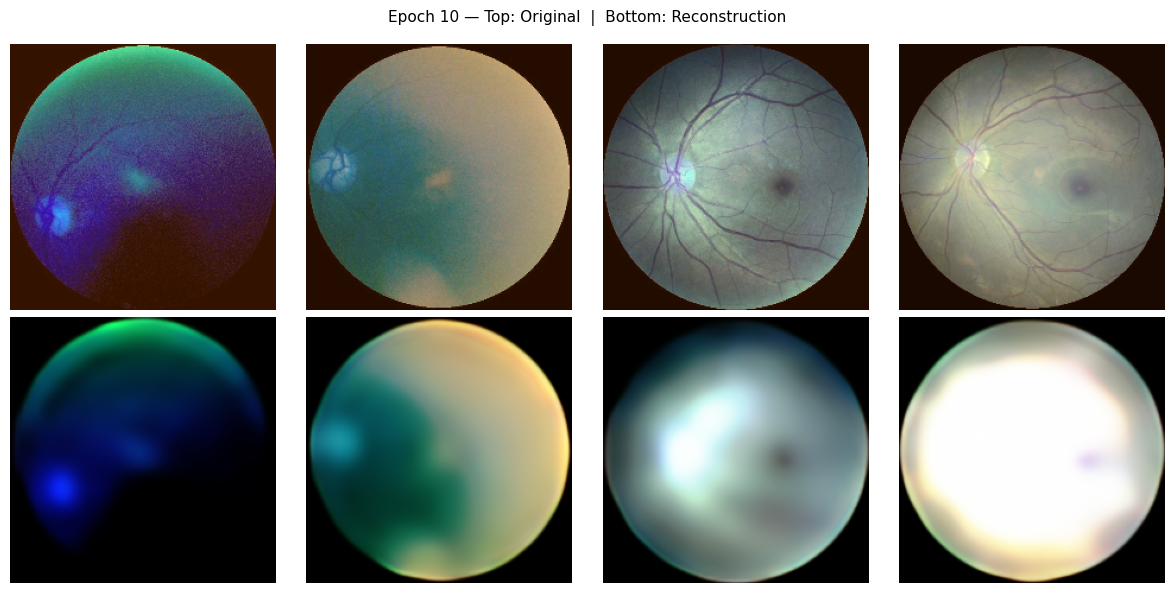

  Epoch [11/50] train Loss: 0.1572 val loss: 0.1529 saved new best
  Epoch [12/50] train Loss: 0.1556 val loss: 0.1530 
  Epoch [13/50] train Loss: 0.1563 val loss: 0.1550 
  Epoch [14/50] train Loss: 0.1580 val loss: 0.1534 
  Epoch [15/50] train Loss: 0.1556 val loss: 0.1519 saved new best
  Epoch [16/50] train Loss: 0.1549 val loss: 0.1517 saved new best
  Epoch [17/50] train Loss: 0.1554 val loss: 0.1517 saved new best
  Epoch [18/50] train Loss: 0.1559 val loss: 0.1530 
  Epoch [19/50] train Loss: 0.1538 val loss: 0.1499 saved new best
  Epoch [20/50] train Loss: 0.1507 val loss: 0.1495 saved new best


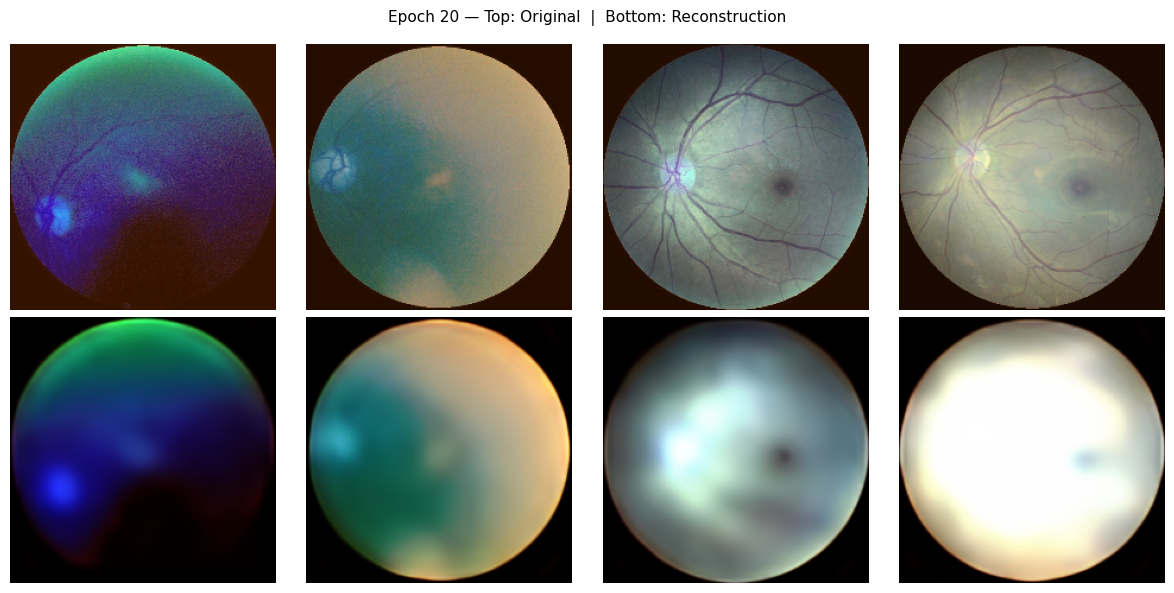

  Epoch [21/50] train Loss: 0.1518 val loss: 0.1522 
  Epoch [22/50] train Loss: 0.1535 val loss: 0.1510 
  Epoch [23/50] train Loss: 0.1518 val loss: 0.1531 
  Epoch [24/50] train Loss: 0.1553 val loss: 0.1503 
  Epoch [25/50] train Loss: 0.1511 val loss: 0.1477 saved new best
  Epoch [26/50] train Loss: 0.1480 val loss: 0.1487 
  Epoch [27/50] train Loss: 0.1509 val loss: 0.1472 saved new best
  Epoch [28/50] train Loss: 0.1491 val loss: 0.1478 
  Epoch [29/50] train Loss: 0.1505 val loss: 0.1489 
  Epoch [30/50] train Loss: 0.1509 val loss: 0.1488 


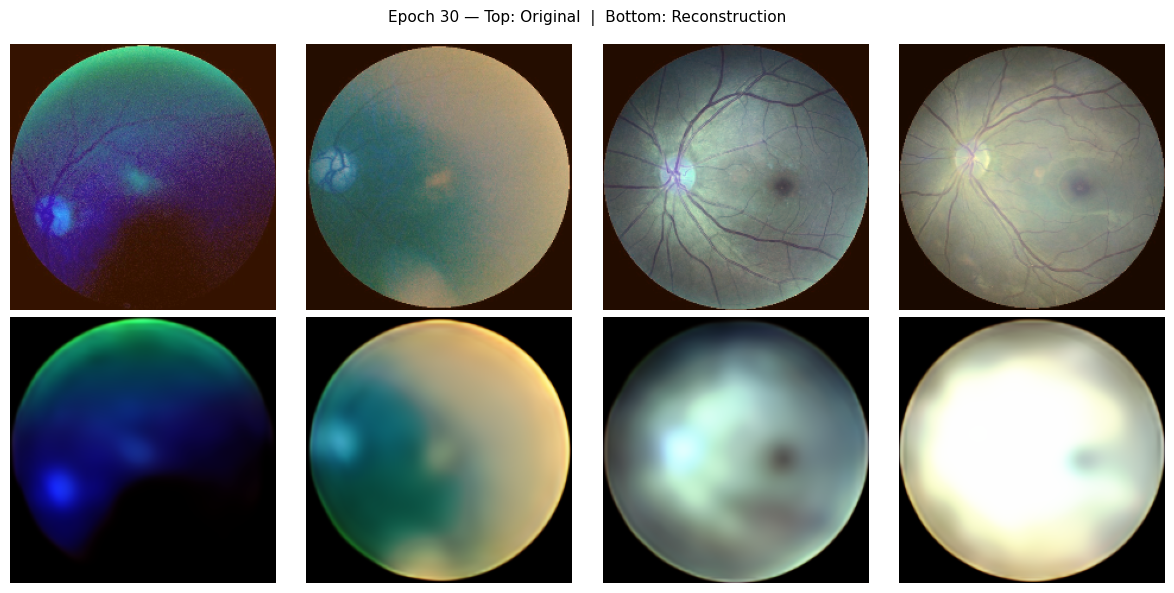

  Epoch [31/50] train Loss: 0.1495 val loss: 0.1487 
  Epoch [32/50] train Loss: 0.1485 val loss: 0.1470 saved new best
  Epoch [33/50] train Loss: 0.1470 val loss: 0.1479 
  Epoch [34/50] train Loss: 0.1471 val loss: 0.1467 saved new best
  Epoch [35/50] train Loss: 0.1500 val loss: 0.1476 
  Epoch [36/50] train Loss: 0.1479 val loss: 0.1465 saved new best
  Epoch [37/50] train Loss: 0.1467 val loss: 0.1466 
  Epoch [38/50] train Loss: 0.1472 val loss: 0.1466 
  Epoch [39/50] train Loss: 0.1469 val loss: 0.1472 
  Epoch [40/50] train Loss: 0.1489 val loss: 0.1464 saved new best


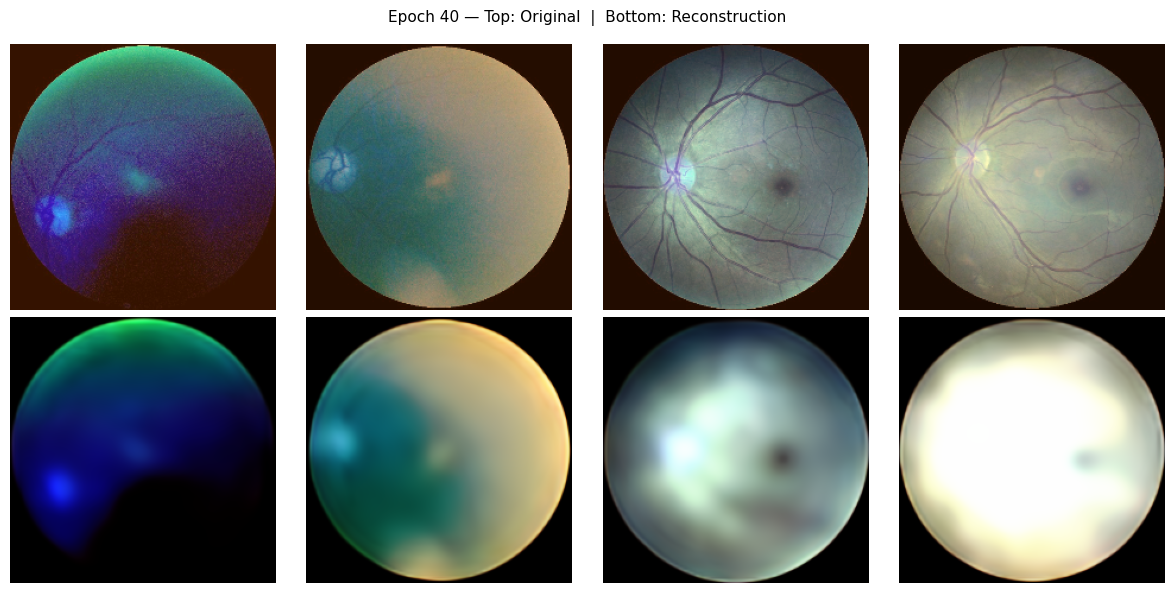

  Epoch [41/50] train Loss: 0.1484 val loss: 0.1469 
  Epoch [42/50] train Loss: 0.1474 val loss: 0.1464 saved new best
  Epoch [43/50] train Loss: 0.1465 val loss: 0.1467 
  Epoch [44/50] train Loss: 0.1484 val loss: 0.1466 
  Epoch [45/50] train Loss: 0.1476 val loss: 0.1488 
  Epoch [46/50] train Loss: 0.1470 val loss: 0.1469 
  Epoch [47/50] train Loss: 0.1462 val loss: 0.1463 saved new best
  Epoch [48/50] train Loss: 0.1464 val loss: 0.1463 
  Epoch [49/50] train Loss: 0.1465 val loss: 0.1460 saved new best
  Epoch [50/50] train Loss: 0.1464 val loss: 0.1461 


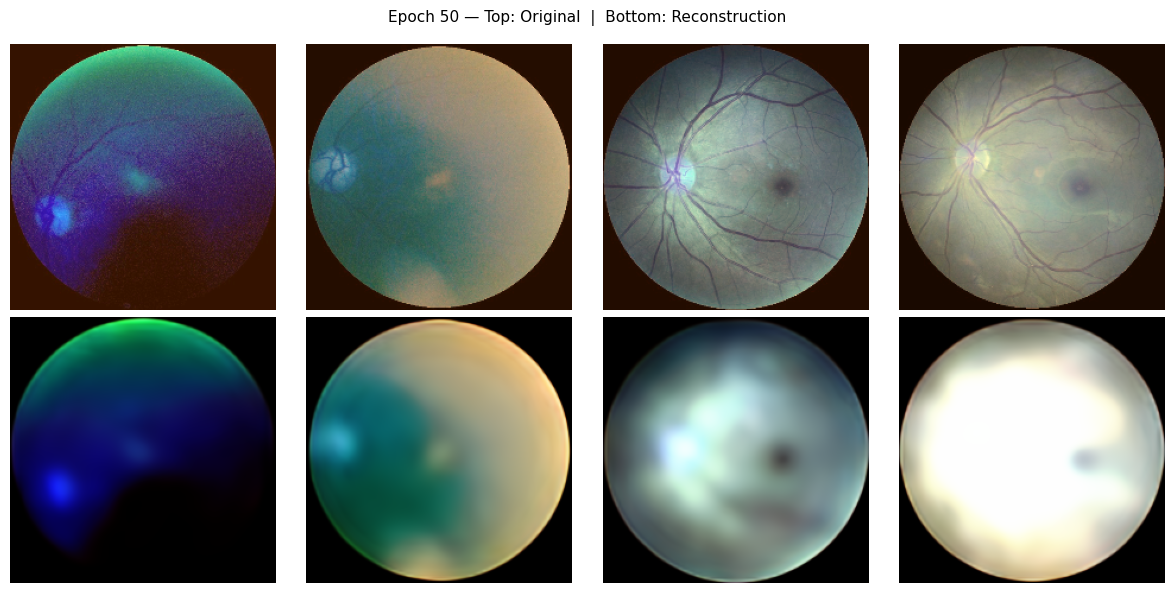

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001, weight_decay=0.00001)
#reduces learning rate by half if it val loss stops improving for patience epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs_AE = 50
patience_count = 0
patience = 7
best_val_loss = float('inf')

train_losses = []
val_losses = []


print("Starting Autoencoder training... 🔬")
print(f"Training for {num_epochs_AE} epochs\n")

for epoch in range(num_epochs_AE):
    autoencoder.train()
    running_loss = 0.0
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        recon = autoencoder(imgs)
        loss = criterion(recon, targets)
        #loss = combined_loss(recon, targets, alpha=0.5)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    autoencoder.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            recon = autoencoder(imgs)
            val_loss += criterion(recon, targets).item()
            #val_loss += combined_loss(recon, targets, alpha=0.5).item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_count = 0
        torch.save(autoencoder.state_dict(), 'best_autoencoder.pth')
        saved = 'saved new best'
    else:
        patience_count += 1
        saved = ''
        
    print(f" Epoch [{epoch+1:2d}/{num_epochs_AE}] train Loss: {train_loss:.4f} val loss: {avg_val:.4f} {saved}")

    #visualization
    if (epoch + 1) % 10 == 0:
        autoencoder.eval()
        with torch.no_grad():
            imgs, _ = next(iter(val_loader))
            imgs = imgs[:4].to(device)
            recons = autoencoder(imgs)

        fig, axes = plt.subplots(2, 4, figsize=(12, 6))
        fig.suptitle(f'Epoch {epoch+1} — Top: Original  |  Bottom: Reconstruction', fontsize=11)

        for i in range(4):
            orig = imgs[i].cpu().permute(1, 2, 0).numpy()
            recon = recons[i].cpu().permute(1, 2, 0).numpy()
            orig = (orig  - orig.min())  / (orig.max() - orig.min() + 1e-8)
            recon = (recon - recon.min()) / (recon.max() - recon.min() + 1e-8)

            axes[0, i].imshow(orig)
            axes[0, i].axis('off')
            axes[1, i].imshow(recon)
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()

    if patience_count >= patience:
        print(f'Early stopping triggered at epoch {epoch}\n')
        break



Fine-tuning with MSE + SSIM loss... 🔬
  Epoch [ 1/30] train: 0.2515  val: 0.2405  saved new best
  Epoch [ 2/30] train: 0.2408  val: 0.2307  saved new best
  Epoch [ 3/30] train: 0.2355  val: 0.2288  saved new best
  Epoch [ 4/30] train: 0.2329  val: 0.2269  saved new best
  Epoch [ 5/30] train: 0.2300  val: 0.2245  saved new best
  Epoch [ 6/30] train: 0.2290  val: 0.2235  saved new best
  Epoch [ 7/30] train: 0.2267  val: 0.2228  saved new best
  Epoch [ 8/30] train: 0.2261  val: 0.2205  saved new best
  Epoch [ 9/30] train: 0.2264  val: 0.2221  
  Epoch [10/30] train: 0.2255  val: 0.2202  saved new best


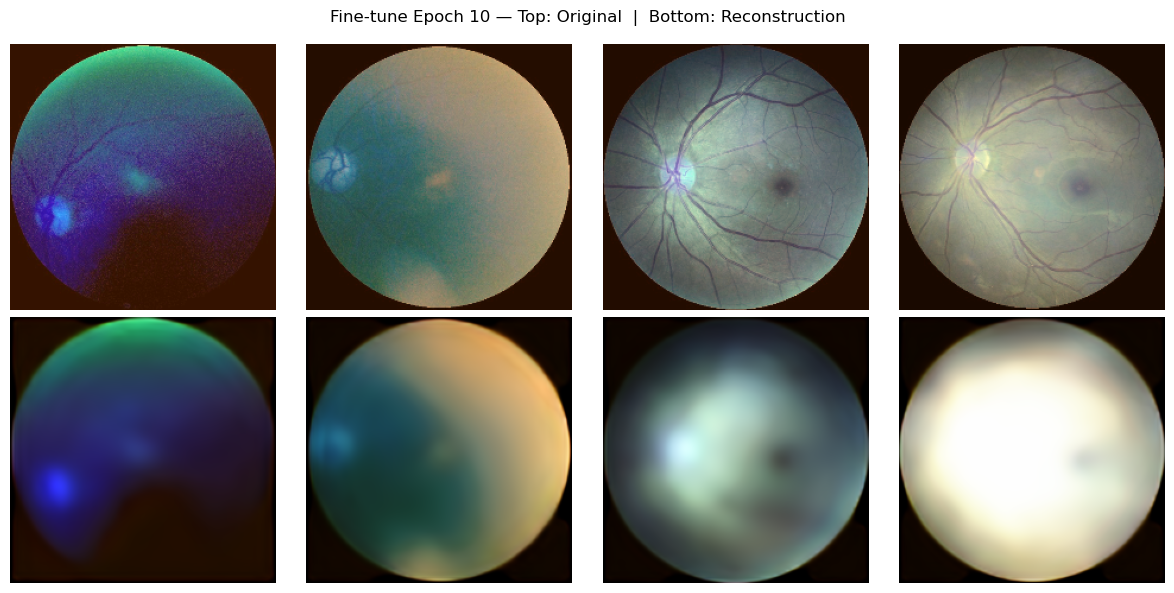

  Epoch [11/30] train: 0.2245  val: 0.2192  saved new best
  Epoch [12/30] train: 0.2228  val: 0.2186  saved new best
  Epoch [13/30] train: 0.2232  val: 0.2187  
  Epoch [14/30] train: 0.2224  val: 0.2185  saved new best
  Epoch [15/30] train: 0.2223  val: 0.2175  saved new best
  Epoch [16/30] train: 0.2221  val: 0.2173  saved new best
  Epoch [17/30] train: 0.2218  val: 0.2175  
  Epoch [18/30] train: 0.2224  val: 0.2210  
  Epoch [19/30] train: 0.2215  val: 0.2166  saved new best
  Epoch [20/30] train: 0.2215  val: 0.2164  saved new best


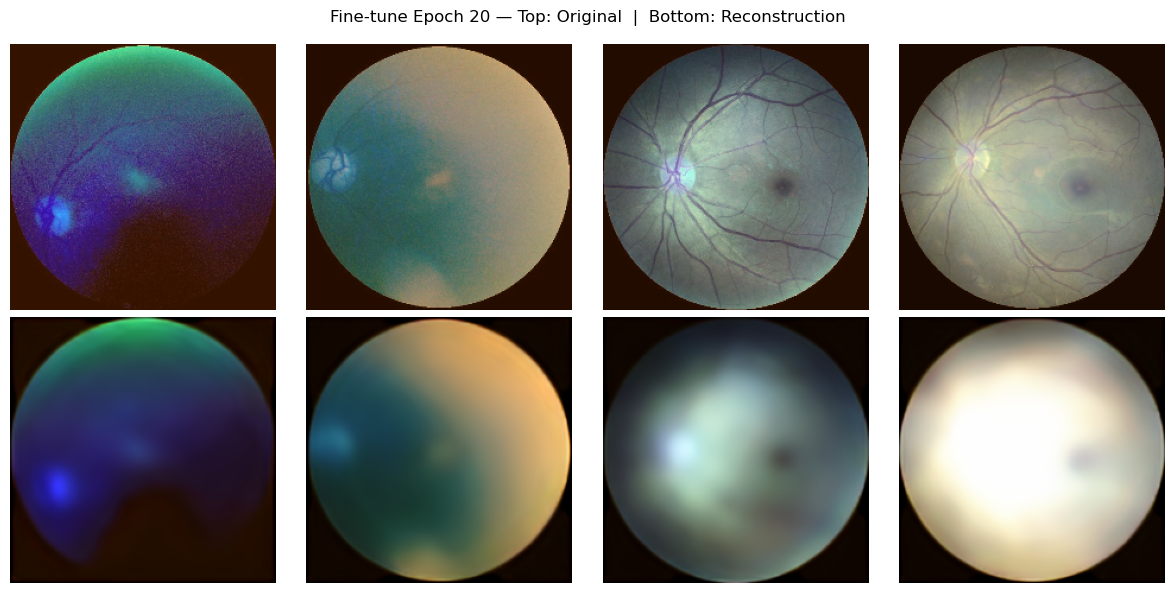

  Epoch [21/30] train: 0.2214  val: 0.2163  saved new best
  Epoch [22/30] train: 0.2209  val: 0.2165  
  Epoch [23/30] train: 0.2213  val: 0.2163  saved new best
  Epoch [24/30] train: 0.2209  val: 0.2170  
  Epoch [25/30] train: 0.2209  val: 0.2153  saved new best
  Epoch [26/30] train: 0.2203  val: 0.2153  saved new best
  Epoch [27/30] train: 0.2210  val: 0.2179  
  Epoch [28/30] train: 0.2203  val: 0.2157  
  Epoch [29/30] train: 0.2204  val: 0.2154  
  Epoch [30/30] train: 0.2199  val: 0.2162  


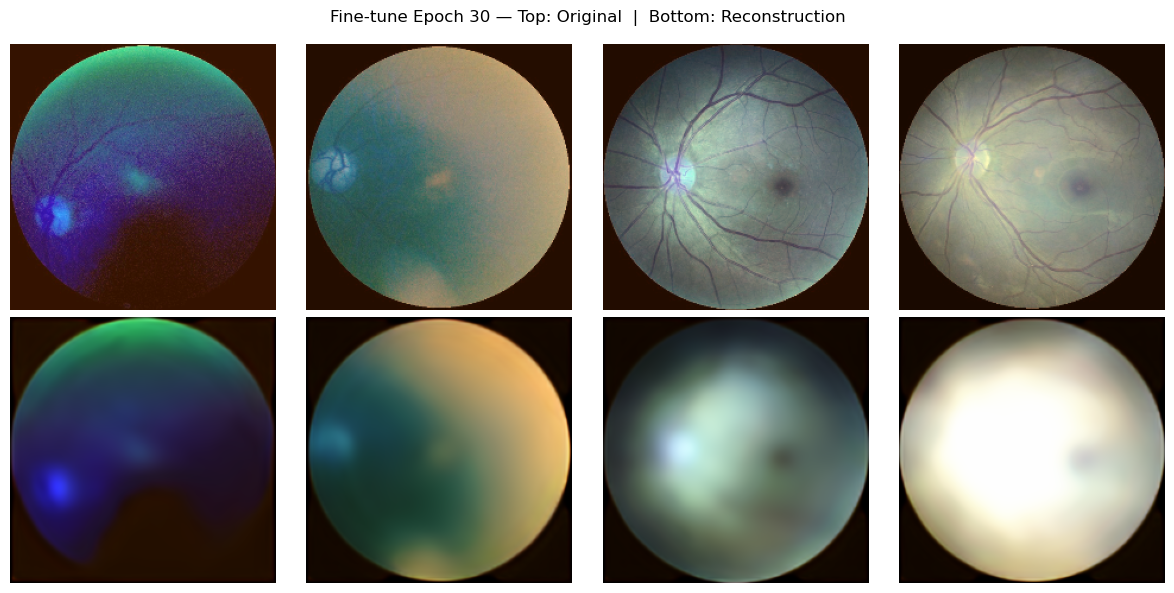

In [13]:
#Attempt to update with SSIM loss, pure MSE ended up being better
autoencoder.load_state_dict(torch.load('best_autoencoder.pth'))

optimizer = optim.Adam(autoencoder.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs_finetune = 30
patience_count = 0
patience = 7
best_val_loss = float('inf')
train_losses_ft = []
val_losses_ft = []

print("Fine-tuning with MSE + SSIM loss... 🔬")

for epoch in range(num_epochs_finetune):
    autoencoder.train()
    running_loss = 0.0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        recon = autoencoder(imgs)
        loss = combined_loss(recon, targets, alpha=0.5)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses_ft.append(train_loss)

    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            recon = autoencoder(imgs)
            val_loss += combined_loss(recon, targets, alpha=0.5).item()

    avg_val = val_loss / len(val_loader)
    val_losses_ft.append(avg_val)
    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        patience_count = 0
        torch.save(autoencoder.state_dict(), 'best_autoencoder_ft.pth')
        saved = 'saved new best'
    else:
        patience_count += 1
        saved = ''

    print(f" Epoch [{epoch+1:2d}/{num_epochs_finetune}] "
          f"train: {train_loss:.4f}  val: {avg_val:.4f}  {saved}")

    if (epoch + 1) % 10 == 0:
        autoencoder.eval()
        with torch.no_grad():
            imgs, _ = next(iter(val_loader))
            imgs = imgs[:4].to(device)
            recons = autoencoder(imgs)

        fig, axes = plt.subplots(2, 4, figsize=(12, 6))
        fig.suptitle(f'Fine-tune Epoch {epoch+1} — Top: Original  |  Bottom: Reconstruction')
        for i in range(4):
            orig = imgs[i].cpu().permute(1, 2, 0).numpy()
            recon = recons[i].cpu().permute(1, 2, 0).numpy()
            orig = (orig  - orig.min()) / (orig.max()  - orig.min()  + 1e-8)
            recon = (recon - recon.min()) / (recon.max() - recon.min() + 1e-8)
            axes[0, i].imshow(orig);  axes[0, i].axis('off')
            axes[1, i].imshow(recon); axes[1, i].axis('off')
        plt.tight_layout()
        plt.show()

    if patience_count >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

Normal test images: 432
Computing reconstruction errors...

  Normal         : n= 432  mean error=0.1389  std=0.2333  (test split only)
  Diabetes       : n=1608  mean error=0.1497  std=0.1825
  Glaucoma       : n= 284  mean error=0.1125  std=0.1997
  Cataract       : n= 293  mean error=0.4459  std=0.9078
  AMD            : n= 266  mean error=0.1358  std=0.1484
  Hypertension   : n= 128  mean error=0.1478  std=0.1597
  Myopia         : n= 232  mean error=0.3370  std=0.3993
  Other          : n= 708  mean error=0.1810  std=0.3097

Anomaly threshold (95th percentile of Normal test): 0.5299

── Detection Rate Above Threshold ───────────────────
  Normal         : 5.1% flagged  (should be ~5%)
  Diabetes       : 4.0% flagged as anomaly
  Glaucoma       : 4.6% flagged as anomaly
  Cataract       : 19.8% flagged as anomaly
  AMD            : 2.6% flagged as anomaly
  Hypertension   : 3.1% flagged as anomaly
  Myopia         : 18.5% flagged as anomaly
  Other          : 5.8% flagged as anomal

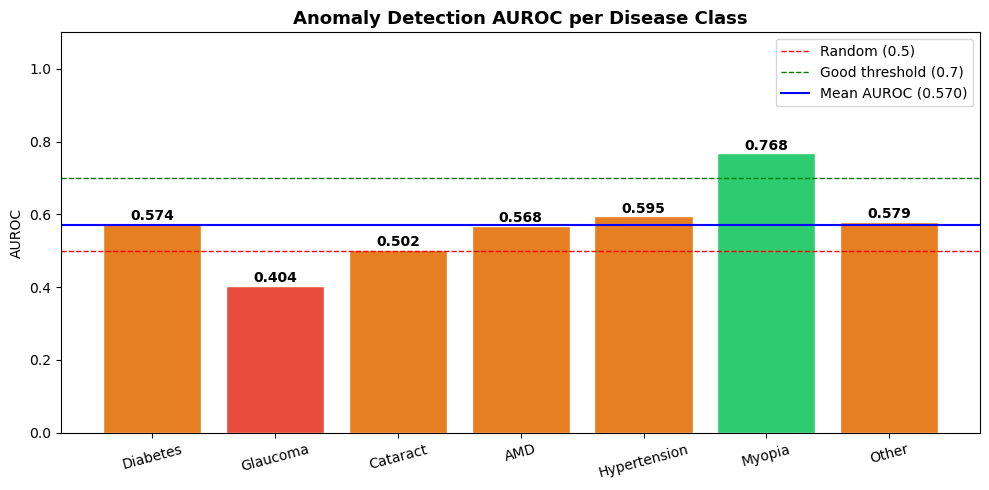

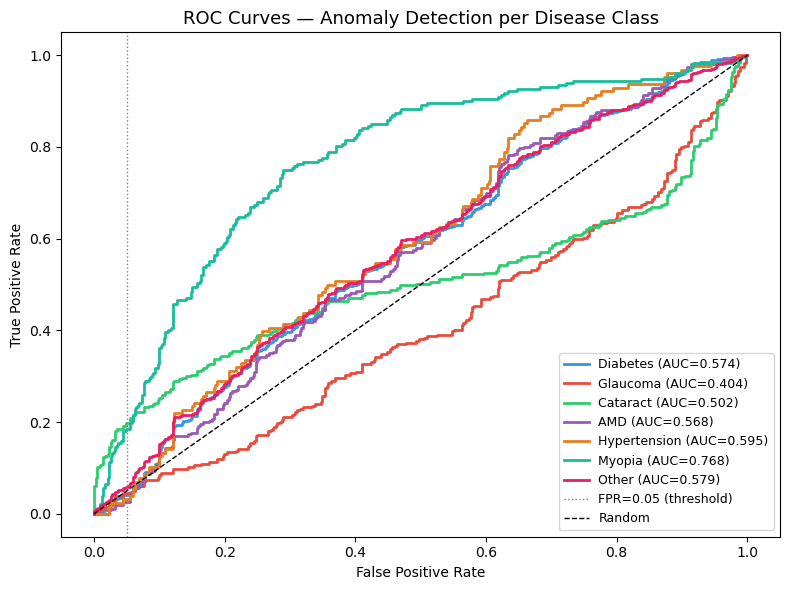

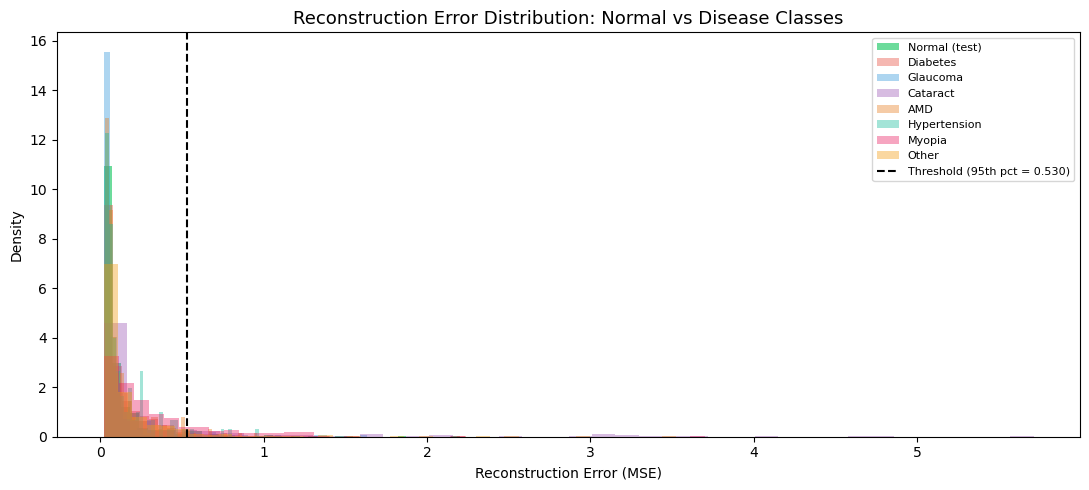

In [18]:
#best model pure mse
autoencoder.load_state_dict(torch.load('best_autoencoder.pth'))
autoencoder.eval()

BASE_DIR = 'C:/Users/deana/Downloads/RetinalDiseaseDetectionAutoencoder/data/datasets'

CLASSES = {
    'Normal'      : os.path.join(BASE_DIR, 'normal'),
    'Diabetes'    : os.path.join(BASE_DIR, 'diabetes'),
    'Glaucoma'    : os.path.join(BASE_DIR, 'glaucoma'),
    'Cataract'    : os.path.join(BASE_DIR, 'cataract'),
    'AMD'         : os.path.join(BASE_DIR, 'ageDegeneration'),
    'Hypertension': os.path.join(BASE_DIR, 'hypertension'),
    'Myopia'      : os.path.join(BASE_DIR, 'myopia'),
    'Other'       : os.path.join(BASE_DIR, 'others'),
}

class EvalDataset(Dataset):
    def __init__(self, folder, transform, files=None):
        self.folder = folder
        self.transform = transform
        self.files = files if files is not None else sorted([
            f for f in os.listdir(folder)
            if f.endswith(('.jpg', '.jpeg', '.png'))
        ])
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.folder, self.files[idx])).convert('RGB')
        return self.transform(img)

def compute_errors(folder, transform, batch_size=32, files=None):
    dataset = EvalDataset(folder, transform, files=files)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    errors = []
    with torch.no_grad():
        for imgs in loader:
            imgs = imgs.to(device)
            recon = autoencoder(imgs)
            err = ((recon - imgs) ** 2).mean(dim=[1, 2, 3])
            errors.extend(err.cpu().numpy())
    return np.array(errors)


normal_test_files = [dataset.files[i] for i in test_set.indices]
print(f'Normal test images: {len(normal_test_files)}')

print('Computing reconstruction errors...\n')
all_errors = {}

normal_test_errors = compute_errors(dataPath, transform, files=normal_test_files)
all_errors['Normal'] = normal_test_errors
print(f' {"Normal":<15}: n={len(normal_test_errors):>4}  '
      f'mean error={normal_test_errors.mean():.4f}  '
      f'std={normal_test_errors.std():.4f}  (test split only)')

for class_name, folder in CLASSES.items():
    if class_name == 'Normal':
        continue
    if not os.path.exists(folder):
        print(f' Skipping {class_name} — folder not found: {folder}')
        continue
    errors = compute_errors(folder, transform)
    all_errors[class_name] = errors
    print(f' {class_name:<15}: n={len(errors):>4}  '
          f'mean error={errors.mean():.4f}  '
          f'std={errors.std():.4f}')

#current threshold 95
threshold = np.percentile(normal_test_errors, 95)
print(f'\nAnomaly threshold (95th percentile of Normal test): {threshold:.4f}')
print(f'\n── Detection Rate Above Threshold ───────────────────')
normal_flagged = (normal_test_errors > threshold).mean()
print(f' {"Normal":<15}: {100*normal_flagged:.1f}% flagged should be ~5%)')

for class_name, errors in all_errors.items():
    if class_name == 'Normal':
        continue
    detection_rate = (errors > threshold).mean()
    print(f'  {class_name:<15}: {100*detection_rate:.1f}% flagged as anomaly')

print('\n── AUROC per Disease Class ──────────────────────────────')
normal_errors = all_errors['Normal']
auroc_scores  = {}

for class_name, errors in all_errors.items():
    if class_name == 'Normal':
        continue
    labels = np.array([0] * len(normal_errors) + [1] * len(errors))
    scores = np.concatenate([normal_errors, errors])
    auroc  = roc_auc_score(labels, scores)
    auroc_scores[class_name] = auroc
    print(f'  {class_name:<15}: AUROC = {auroc:.4f}')

mean_auroc = np.mean(list(auroc_scores.values()))
print(f'\n  Mean AUROC (all classes): {mean_auroc:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
names = list(auroc_scores.keys())
scores = list(auroc_scores.values())
colors = ['#2ecc71' if s >= 0.7 else '#e67e22' if s >= 0.5 else '#e74c3c' for s in scores]

bars = ax.bar(names, scores, color=colors, edgecolor='white')
ax.axhline(0.5, color='red',   linestyle='--', linewidth=1, label='Random (0.5)')
ax.axhline(0.7, color='green', linestyle='--', linewidth=1, label='Good threshold (0.7)')
ax.axhline(mean_auroc, color='blue', linestyle='-', linewidth=1.5,
           label=f'Mean AUROC ({mean_auroc:.3f})')

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('AUROC')
ax.set_title('Anomaly Detection AUROC per Disease Class', fontsize=13, fontweight='bold')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22','#1abc9c','#e91e63']

for (class_name, errors), color in zip(
        {k: v for k, v in all_errors.items() if k != 'Normal'}.items(), colors_roc):
    labels = np.array([0] * len(normal_errors) + [1] * len(errors))
    scores = np.concatenate([normal_errors, errors])
    fpr, tpr, _ = roc_curve(labels, scores)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{class_name} (AUC={auroc_scores[class_name]:.3f})')

ax.axvline(x=0.05, color='gray', linestyle=':', linewidth=1, label='FPR=0.05 (threshold)')
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Anomaly Detection per Disease Class', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(normal_errors, bins=40, alpha=0.7, color='#2ecc71', label='Normal (test)', density=True)

colors_dist = ['#e74c3c','#3498db','#9b59b6','#e67e22','#1abc9c','#e91e63','#f39c12']
for (class_name, errors), color in zip(
        {k: v for k, v in all_errors.items() if k != 'Normal'}.items(), colors_dist):
    ax.hist(errors, bins=40, alpha=0.4, color=color, label=class_name, density=True)

ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold (95th pct = {threshold:.3f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Reconstruction Error Distribution: Normal vs Disease Classes', fontsize=13)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()